In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
import os
from importlib import reload
import re
import time
current_dir = os.path.abspath('')
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

import util
import util_working
from jax import numpy as jnp

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
''' Parameter for the model '''
rho_dm = 0.025
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])
params = jnp.transpose(jnp.vstack((rhos, sigmas)))

In [4]:
def bounds(mean, std):
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    mu_ = jnp.exp(mu)
    sigma_ = jnp.exp(sigma)
    return mu_/sigma_, mu_*sigma_

def extract_values(s):
    z2_match = re.search(r'z2:(\d+\.?\d*)', s)
    z1_match = re.search(r'z1:(\d+\.?\d*)', s)
    pn_match = re.search(r'data:(\w+)', s)
    name_match = re.search(r'n:(\w+)', s)
    
    z2_value = float(z2_match.group(1)) if z2_match else None
    z1_value = float(z1_match.group(1)) if z1_match else None
    pn_value = pn_match.group(1) if pn_match else None
    name_value = name_match.group(1) if name_match else None
    
    return z2_value, z1_value, pn_value, name_value

def find_row_index(file_path, z2_target, z1_target, pn_target, name_target):
    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            z2_value, z1_value, pn_value, name_value = extract_values(line)
            if z2_value == z2_target and z1_value == z1_target and pn_value == pn_target and name_value == name_target:
                index = i
                break
    
    return index

def read_res(file_rho, file_rd, file_sigma, file_sd, file_cf):
    rho = jnp.array(pd.read_csv(file_rho, header=None).iloc[:,1])
    erho = jnp.array(pd.read_csv(file_rho, header=None).iloc[:,2])
    rd = jnp.array(pd.read_csv(file_rd, header=None).iloc[:,1])
    erd = jnp.array(pd.read_csv(file_rd, header=None).iloc[:,2])
    sigma = jnp.array(pd.read_csv(file_sigma, header=None).iloc[:,1])
    esigma = jnp.array(pd.read_csv(file_sigma, header=None).iloc[:,2])
    sd = jnp.array(pd.read_csv(file_sd, header=None).iloc[:,1])
    esd = jnp.array(pd.read_csv(file_sd, header=None).iloc[:,2])
    param = jnp.column_stack((rho, sigma))
    cf = pd.read_csv(file_cf, header=None).iloc[:,4]
    e_cf = pd.read_csv(file_cf, header=None).iloc[:,5]
    v2 = pd.read_csv(file_cf, header=None).iloc[:,1]
    return rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, v2

def read_samples(file_rho, file_rd, file_sigma, file_sd, file_cf):
    rhos = np.array(pd.read_csv(file_rho, header=None).iloc[:,3])
    rds = np.array(pd.read_csv(file_rd, header=None).iloc[:,3])
    sigmas = np.array(pd.read_csv(file_sigma, header=None).iloc[:,3])
    sds = np.array(pd.read_csv(file_sd, header=None).iloc[:,3])
    return rhos, rds, sigmas, sds

In [5]:
def plot_params(subsample, include, title=None):
    ''' Parameter for the model '''
    rho, erho, rd, erd, sigma, esigma, sd, esd, param, _, _, _ = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].set_title(title)
    plt.title(f'[{subsample}]')
    colors = ['red', 'purple', 'green', 'orange', 'blue', 'black', 'brown', 'pink', 'gray', 'yellow', 'cyan', 'magenta', 'olive', 'lime', 'teal']

    j = 0
    for set in include:
        i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        ax[0].errorbar(rhos+j*0.00012, rho[i*15:(i+1)*15], yerr=erho[i*15:(i+1)*15], fmt='o', alpha=0.7, color = colors[j])
        ax[1].errorbar(sigmas+j*0.6, sigma[i*15:(i+1)*15], yerr=esigma[i*15:(i+1)*15], fmt='o', label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[3]}', alpha=0.7, color = colors[j])
        plt.figtext(0.15, 0.84-j*0.04, f'$\Sigma$ = ({sd[i]:.3f} +/- {esd[i]:.3f}) M_sun/pc^2', fontsize=18, color = colors[j])
        
        j += 1

    ax[0].plot([0, 0.022], [0, 0.022], color='black', linestyle='--')
    rho_sorted = np.argsort(rhos)
    ax[0].fill_between(rhos[rho_sorted], (rhos+erhos)[rho_sorted], y2=(rhos-erhos)[rho_sorted], alpha=0.1, color='gray', label='gauß 0.683')
    ax[0].fill_between(rhos[rho_sorted], bounds(rhos[rho_sorted], erhos[rho_sorted])[0], y2=bounds(rhos[rho_sorted], erhos[rho_sorted])[1], alpha=0.1, color='blue', label='lognormal 0.683')
    ax[0].set_xlabel("True rho")
    ax[0].set_ylabel("Inferred rho")
    ax[0].grid()
    ax[0].legend(fontsize='16')

    ax[1].plot([0, 110], [0, 110], color='black', linestyle='--')
    sigma_sorted = np.argsort(sigmas)
    ax[1].fill_between(sigmas[sigma_sorted], (sigmas+esigmas)[sigma_sorted], y2=(sigmas-esigmas)[sigma_sorted], alpha=0.1, color='gray')
    ax[1].fill_between(sigmas[sigma_sorted], bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[0], y2=bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[1], alpha=0.1, color='blue')
    ax[1].set_xlabel("True sigma")
    ax[1].set_ylabel("Inferred sigma")
    ax[1].grid()
    ax[1].legend(fontsize='16')
    fig.set_dpi(50)
    plt.show()

In [6]:
reload(util)
reload(util_working)

def plot_fits(subsample, include, title=None):
    ''' real data '''
    n_real = np.loadtxt(f'n_{subsample}.txt')
    bins = np.loadtxt(f'bins_{subsample}.txt')
    zz_real = (bins[1:]+bins[:-1])/2
    pos = np.where(zz_real >= 0)
    neg = np.where(zz_real < 0)
    n_sum = (n_real[pos]+np.flip(n_real[neg]))

    ''' Domain '''
    z2 = 0.
    z1 = max(bins)
    poly = np.loadtxt(f'poly_{subsample}.txt')
    poly_sq = (20./1200., 17.)
    poly_sqrt = (400.**2/1200, 300.**2/2)
    poly_lin = (700./1500, 300.)
    poly_lin2 = (2200./1500, 300.)
    i2 = np.where(bins<=z2)[0][-1]
    i1 = np.where(bins>=z1)[0][0]
    z2 = bins[i2]
    z1 = bins[i1]
    n = int(z1)+1
    n_bins = int(len(bins[i2:i1+1])-1)

    ''' Parameter for the model '''
    rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, v2 = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(2,1, figsize=(20,20))
    ax[0].set_title(title)
    colors = ['red', 'purple', 'green', 'orange', 'blue', 'black', 'brown', 'pink', 'gray', 'yellow', 'cyan', 'magenta', 'olive', 'lime', 'teal']

    ax[0].errorbar(zz_real[pos], n_sum, yerr=np.sqrt(n_sum), label=f"{subsample} both")

    ax[0].set_yscale("log")
    ax[0].set_xlabel("Height z above/below galactic centerplane in pc")
    ax[0].set_ylabel("#K-type stars")

    ax[1].plot(zz_real[pos], poly[0]*zz_real[pos]+poly[1], ls='-', label=f"{subsample} fit", linewidth=2, c='black')
    # ax[1].plot(zz_real[pos], (poly_sq[1] + poly_sq[0]*zz_real[pos])**2, linewidth=2, ls='-.', c='black', label='readsq')
    # ax[1].plot(zz_real[pos], jnp.sqrt(poly_sqrt[1] + poly_sqrt[0]*zz_real[pos]), linewidth=2, ls=':', label='readsqrt', c='black')
    # ax[1].plot(zz_real[pos], poly_lin[1] + poly_lin[0] *zz_real[pos], linewidth=2, ls='--', c='black', label='readlin')
    # ax[1].plot(zz_real[pos], poly_lin2[1] + poly_lin2[0] *zz_real[pos], linewidth=2, ls='--', c='black', label='readlin2')
    
    j=0
    for set in include:
        i2_ = np.where(bins == set[0])[0][0] - len(bins)//2
        i1_ = np.where(bins == set[1])[0][0] - len(bins)//2
        i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        cf_i = jnp.array([float(el) for el in cf[i].strip('[]').split()])
        ecf_i = jnp.array([float(el) for el in e_cf[i].strip('[]').split()])
        v2_i = jnp.array([float(el) for el in v2[i].strip('[]').split()])	
    
        ''' calculated data'''
        uz, zs = util_working.diffraxDopri5(rd[i], param[i*15:(i+1)*15], z1, n)

        vdfo_norm_calc_old, z_old = util.vdfo_norm(z2, z1, zs, uz, n, poly)
        integral_old, z_borders_old = util.binning(vdfo_norm_calc_old, z_old, z2, z1, n, n_bins)
        n__old = integral_old / sum(integral_old[i2_:i1_]) * sum(n_sum[i2_:i1_])
        zz_old = (z_borders_old[1:] + z_borders_old[:-1]) / 2

        vdfo_norm_calc, z, sig2 = util_working.vdfo_norm(z2, z1, zs, uz, n, poly, cf_i, v2_i)
        integral, z_borders = util_working.binning(vdfo_norm_calc, z, z2, z1, n, n_bins)
        n_ = integral / sum(integral[i2_:i1_]) * sum(n_sum[i2_:i1_])
        zz = (z_borders[1:] + z_borders[:-1]) / 2

        ax[0].plot(zz, n_, label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[3]}', color=colors[j])
        # ax[0].plot(zz_old, n__old, label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]} fit old', color=colors[j], linestyle='--')
        plt.figtext(0.15, 0.65-j*0.02, f'rho_dm = ({rd[i]:.4f} +/- {erd[i]:.4f}) M_sun/pc^3', color=colors[j], fontsize=18)

        grid = jnp.linspace(0, set[1], int(set[1])+1)
        ax[1].plot(grid, cf_i, label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[3]}', color=colors[j])
        ax[1].fill_between(grid, cf_i+ecf_i, cf_i-ecf_i, alpha=0.1, color=colors[j])

        #ax[1].plot(grid, (10./1200.*grid+17.)**2, label='read')

        j+=1
    ax[0].legend(fontsize='18')
    ax[0].grid(which='both')
    ax[1].legend(fontsize='18')
    ax[1].grid(which='both')
    plt.tight_layout()
    fig.set_dpi(50)
    plt.show()

In [7]:
reload(util)
reload(util_working)

def plot_correl(subsample, include, title=None):

    ''' Samples for the model '''
    rhos, rds, sigmas, sds = read_samples(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv')
    rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, v2 = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [4, 1]})
    # ax = [ax]
    ax[0].set_title(title)
    plt.title(f'[{subsample}]')
    colors = ['red', 'purple', 'green', 'orange', 'blue', 'black', 'brown', 'pink', 'gray', 'yellow', 'cyan', 'magenta', 'olive', 'lime', 'teal']

    j = 0
    for set in include:
        i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        rho_11 = rhos[i*15+10]
        rho_11 = rho_11.strip('()').split(', ')
        rho_11 = np.array([float(item) for item in rho_11])
        sigma_11 = sigmas[i*15+10]
        sigma_11 = sigma_11.strip('()').split(', ')
        sigma_11 = np.array([float(item) for item in sigma_11])
        rho_s = jnp.zeros(rho_11.shape)
        for k in range(15):
            rho_k = rhos[i*15+k]
            rho_k = rho_k.strip('()').split(', ')
            rho_k = np.array([float(item) for item in rho_k])
            rho_s = rho_s+rho_k
        rd = rds[i]
        rd = rd.strip('()').split(', ')
        rd = np.array([float(item) for item in rd])
        ax[0].scatter(rho_s, rd, marker='x', alpha=0.7, color = colors[j])
        ax[1].scatter(rho_11, sigma_11, marker='x', label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[3]}', alpha=0.7, color = colors[j])
        plt.figtext(0.15, 0.84-j*0.04, f'$\Sigma$ = ({sd[i]:.3f} +/- {esd[i]:.3f}) M_sun/pc^2', fontsize=18, color = colors[j])
        
        j += 1

    ax[0].set_xlabel(rf"$\rho_s/M_{{\odot}}pc^{-3}$")
    ax[0].set_ylabel(rf"$\rho_{{dm}}/M_{{\odot}}pc^{-2}$")
    ax[0].set_ylim(0,0.03)
    ax[0].set_xlim(0,0.2)
    ax[1].set_xlim(0.014-0.008, 0.014+0.008)
    ax[1].set_ylim(19-10, 19+10)
    ax[0].grid()
    ax[0].legend(fontsize='16')

    ax[1].set_xlabel(rf"$\rho_1/M_{{\odot}}pc^{-3}$")
    ax[1].set_ylabel(rf"$\sigma_1/kms^{-1}$")
    ax[1].grid()
    ax[1].legend(fontsize='16')
    fig.set_dpi(50)
    plt.show()

In [8]:
def complete(subsample, include, title=None):
    plot_params(subsample, include, title)
    plot_fits(subsample, include, title)
    plot_correl(subsample, include, title)

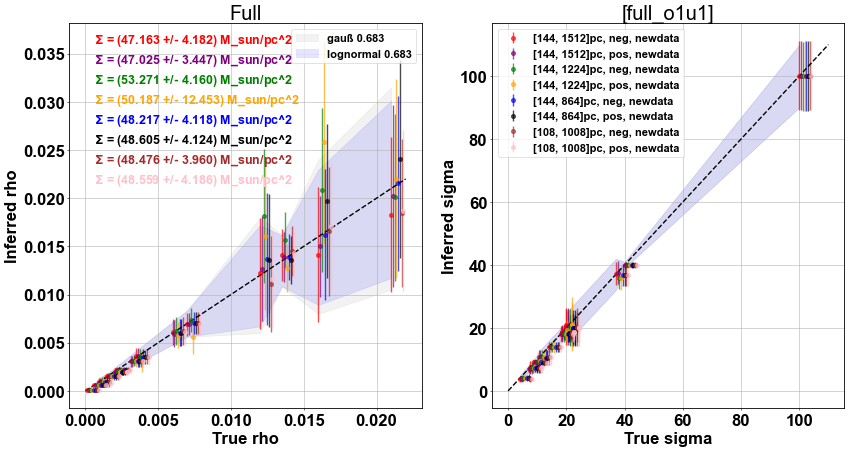

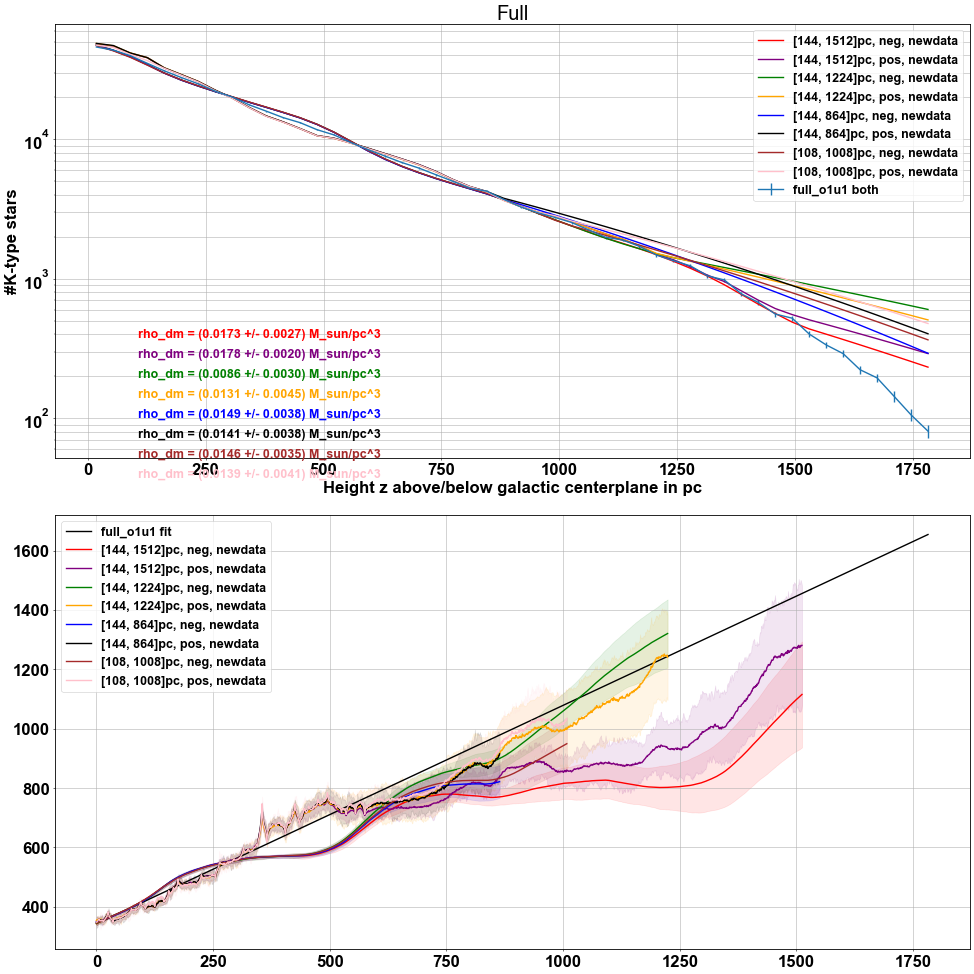

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


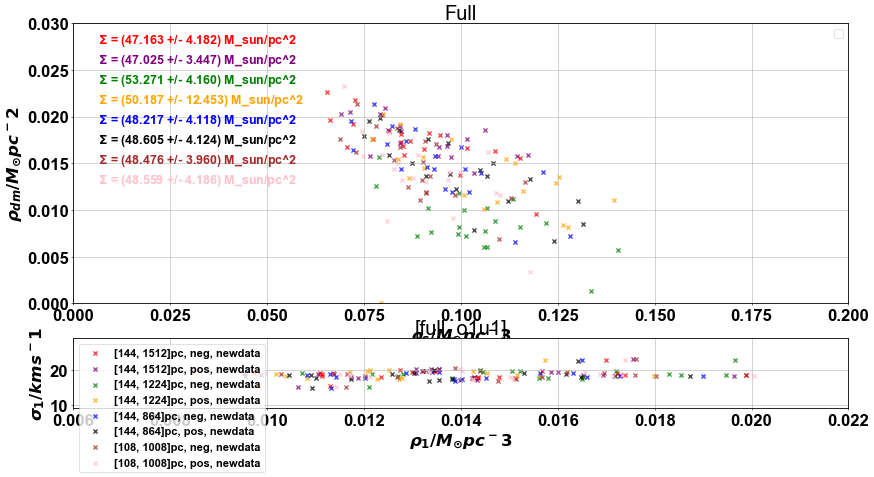

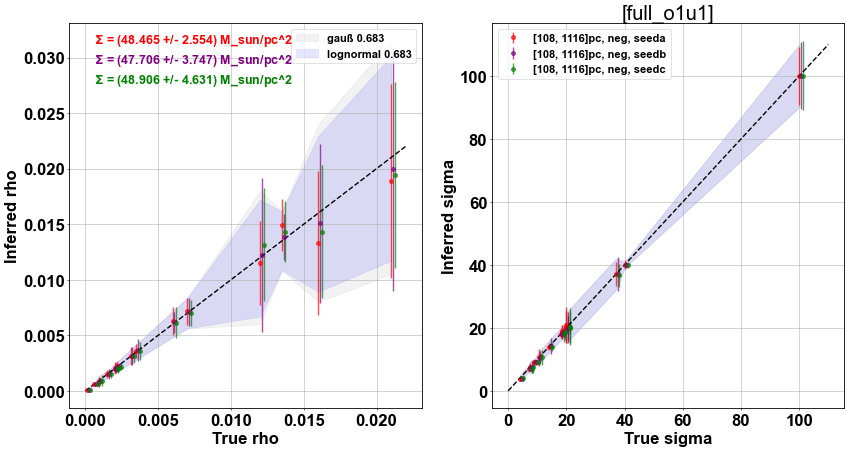

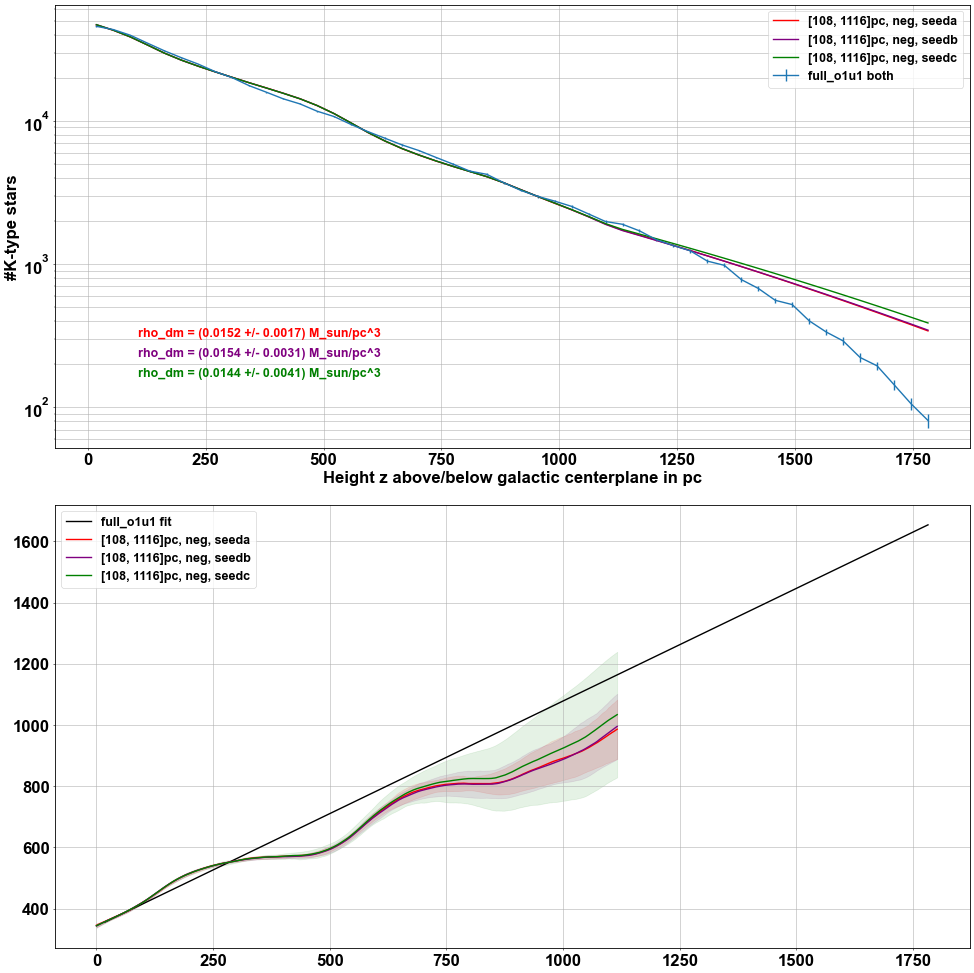

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


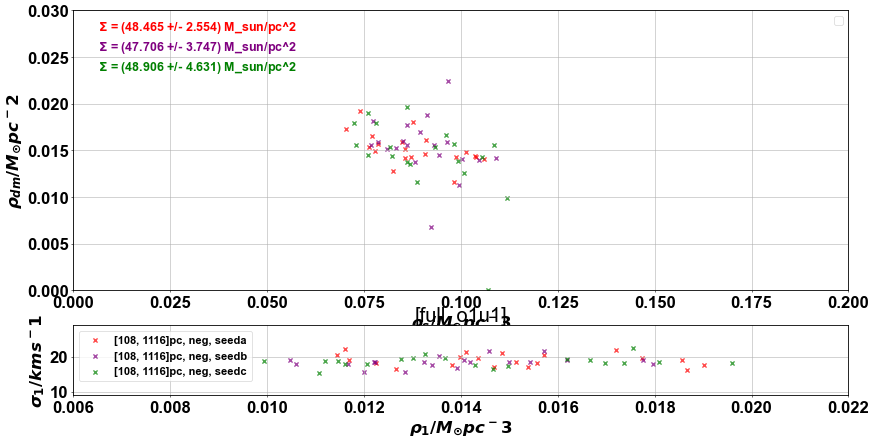

In [9]:
complete('full_o1u1', [[144, 1512, 'neg', 'newdata'], [144, 1512, 'pos', 'newdata'], [144, 1224, 'neg', 'newdata'], [144, 1224, 'pos', 'newdata'], [144, 864, 'neg', 'newdata'], [144, 864, 'pos', 'newdata'], [108, 1008, 'neg', 'newdata'], [108, 1008, 'pos', 'newdata']], 'Full')
complete('full_o1u1', [[108, 1116, 'neg', 'seeda'], [108, 1116, 'neg', 'seedb'], [108, 1116, 'neg', 'seedc']])